**Кластеризация латентных представлений для типизации режимов скважин**

**Цель**: Получить устойчивые кластеры в латентном пространстве автоэнкодера,
интерпретировать каждый кластер как типовой режим работы скважины и сравнить
качество разделения с baseline (EDA этап, Уровни 1–2).

**Входные данные**:
- models/ecn/model.pth   — лучший автоэнкодер ЭЦН
- models/shgn/model.pth  — лучший автоэнкодер ШГН
- data/processed/X_ecn_{train,val,test}.npy, scaler_ecn.pkl
- data/processed/X_shgn_{train,val,test}.npy, scaler_shgn.pkl
- data/processed/window_sizes.json

**Этапы**:
1. Загрузка моделей и данных
2. Кодирование всего датасета → матрица латентных векторов
3. Подбор числа кластеров (Elbow + Silhouette)
4. K-Means кластеризация + сохранение центроидов
5. Оценка качества: Silhouette, Davies-Bouldin, Calinski-Harabasz
6. Визуализация латентного пространства (PCA-2D / UMAP)
7. Интерпретация кластеров: декодирование центроидов → типовые профили
8. Сохранение артефактов кластеризации

**Выходные данные**:
- models/ecn/ecn_kmeans.pkl   — K-Means модель ЭЦН
- models/shgn/shgn_kmeans.pkl  — K-Means модель ШГН
- models/ecn/ecn_labels.npy   — метки кластеров для всех окон ЭЦН
- models/shgn/shgn_labels.npy  — метки кластеров для всех окон ШГН
- models/ecn/ecn_latents.npy  — латентные векторы ЭЦН
- models/shgn/shgn_latents.npy — латентные векторы ШГН

In [10]:
import json
import logging
import pickle
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Protocol

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler
from torchinfo import summary
from umap import UMAP

sys.path.insert(0, str(Path("../models").resolve()))
from models import build_model

# ==== 1. ЗАГРУЗКА МОДЕЛЕЙ И ДАННЫХ ====

In [19]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler()],
)
logger = logging.getLogger(__name__)


SEED: int = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info("Устройство: %s", DEVICE)

2026-02-25 20:42:07,501 - INFO - Устройство: cuda


In [20]:
@dataclass
class DataConfig:
    data_dir: Path
    models_dir: Path
    feature_columns: list[str]


@dataclass
class WindowConfig:
    window_sizes: dict[str, int]
    strides: dict[str, int]


@dataclass
class ModelConfig:
    input_dim: int
    hidden_size: int
    num_layers: int
    kernel_size: int
    dilation_base: int
    dropout: float


@dataclass
class ClusteringConfig:
    default_k: dict[str, int]
    seed: int
    max_k: int
    elbow_min_k: int
    elbow_max_k: int
    batch_size_encode: int


COLORS: dict[str, str] = {
    "primary": "#2E86AB",
    "secondary": "#A23B72",
    "accent": "#F18F01",
    "success": "#C73E1D",
    "neutral": "#6B7280",
}
CLUSTER_PALETTE: list[str] = [
    "#2E86AB",
    "#A23B72",
    "#F18F01",
    "#C73E1D",
    "#4CAF50",
    "#9C27B0",
]

plt.rcParams.update(
    {
        "figure.figsize": (15, 6),
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.dpi": 100,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
    }
)

DATA_CONFIG = DataConfig(
    data_dir=Path("../data/processed"),
    models_dir=Path("../models"),
    feature_columns=[
        "us_center",
        "us_periph",
        "gas_center",
        "gas_periph",
        "temp",
        "water_center",
        "water_periph",
        "gas_integral",
        "water_integral",
    ],
)

with open(DATA_CONFIG.data_dir / "window_sizes.json") as f:
    window_sizes_loaded: dict[str, int] = json.load(f)

WINDOW_CONFIG = WindowConfig(
    window_sizes=window_sizes_loaded,
    strides={"ecn": 20, "shgn": 15},
)

MODEL_CONFIG = ModelConfig(
    input_dim=len(DATA_CONFIG.feature_columns),
    hidden_size=256,
    num_layers=2,
    kernel_size=5,
    dilation_base=2,
    dropout=0.2,
)

CLUSTERING_CONFIG = ClusteringConfig(
    default_k={"ecn": 3, "shgn": 4},
    seed=SEED,
    max_k=10,
    elbow_min_k=2,
    elbow_max_k=8,
    batch_size_encode=256,
)

In [21]:
def _windows_from_array(X: np.ndarray, window_size: int, stride: int) -> np.ndarray:
    if X.shape[0] < window_size:
        return np.empty((0, window_size, X.shape[1]), dtype=np.float32)
    windows = sliding_window_view(X, window_shape=window_size, axis=0)[::stride]
    return np.transpose(windows, (0, 2, 1)).astype(np.float32)

In [22]:
def load_windows(prefix: str) -> tuple[np.ndarray, StandardScaler]:
    with open(DATA_CONFIG.data_dir / f"scaler_{prefix}.pkl", "rb") as f:
        scaler: StandardScaler = pickle.load(f)

    window_size = WINDOW_CONFIG.window_sizes[prefix]
    stride = WINDOW_CONFIG.strides[prefix]

    splits: list[str] = ["train", "val", "test"]
    windows: list[np.ndarray] = []
    for split in splits:
        X_split = np.load(DATA_CONFIG.data_dir / f"X_{prefix}_{split}.npy").astype(np.float32)
        split_windows = _windows_from_array(X_split, window_size, stride)
        if split_windows.size > 0:
            windows.append(split_windows)

    X_all = np.concatenate(windows)
    logger.info("%s: всего окон=%d | shape=%s", prefix.upper(), X_all.shape[0], X_all.shape)
    return X_all, scaler

In [23]:
X_ecn, scaler_ecn = load_windows("ecn")
X_shgn, scaler_shgn = load_windows("shgn")

2026-02-25 20:42:07,553 - INFO - ECN: всего окон=2052 | shape=(2052, 120, 9)
2026-02-25 20:42:07,572 - INFO - SHGN: всего окон=8343 | shape=(8343, 100, 9)


# ==== 2. ЗАГРУЗКА ВЕСОВ И КОДИРОВАНИЕ ====

In [24]:
class Encodable(Protocol):
    def encode(self, x: torch.Tensor) -> torch.Tensor: ...

In [25]:
def load_model(prefix: str) -> tuple[nn.Module, dict[str, object]]:
    checkpoint: dict[str, object] = torch.load(
        DATA_CONFIG.models_dir / prefix / "model.pth",
        map_location=DEVICE,
        weights_only=False,
    )

    model = build_model(
        arch_name=str(checkpoint["architecture"]),
        input_dim=MODEL_CONFIG.input_dim,
        hidden_size=MODEL_CONFIG.hidden_size,
        latent_dim=int(checkpoint["latent_dim"]),
        num_layers=MODEL_CONFIG.num_layers,
        kernel_size=MODEL_CONFIG.kernel_size,
        dilation_base=MODEL_CONFIG.dilation_base,
        dropout=MODEL_CONFIG.dropout,
    ).to(DEVICE)

    model.load_state_dict(checkpoint["model_state_dict"])  # type: ignore[arg-type]
    model.eval()

    logger.info(
        "%s: arch=%s | latent_dim=%s | metrics=%s",
        prefix.upper(),
        checkpoint["architecture"],
        checkpoint["latent_dim"],
        checkpoint["metrics"],
    )
    return model, checkpoint

In [26]:
model_ecn, ckpt_ecn = load_model("ecn")
model_shgn, ckpt_shgn = load_model("shgn")

2026-02-25 20:42:11,812 - INFO - ECN: arch=GRU | latent_dim=32 | metrics={'val_loss': 0.023371744760156972, 'val_mae': 0.06276164532217038, 'test_loss': 0.026210138354761364, 'test_mae': 0.07521869366918464}
2026-02-25 20:42:11,860 - INFO - SHGN: arch=GRU | latent_dim=32 | metrics={'val_loss': 0.37571727916132536, 'val_mae': 0.5365627916458613, 'test_loss': 0.4362359233927096, 'test_mae': 0.6037786499657097}


In [27]:
for prefix, model, window_size in (
    ("ЭЦН", model_ecn, WINDOW_CONFIG.window_sizes["ecn"]),
    ("ШГН", model_shgn, WINDOW_CONFIG.window_sizes["shgn"]),
):
    model_summary = summary(
        model,
        input_size=(1, window_size, MODEL_CONFIG.input_dim),
        col_names=["input_size", "output_size", "num_params"],
        depth=3,
        verbose=0,
    )
    logger.info("\n%s:\n%s", prefix, model_summary)

2026-02-25 20:42:16,036 - INFO - 
ЭЦН:
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
GRUAutoencoder                           [1, 120, 9]               [1, 120, 9]               --
├─GRU: 1-1                               [1, 120, 9]               [1, 120, 512]             1,592,832
├─AttentionPool: 1-2                     [1, 120, 512]             [1, 512]                  --
│    └─Linear: 2-1                       [1, 120, 512]             [1, 120, 1]               513
├─Linear: 1-3                            [1, 512]                  [1, 32]                   16,416
├─Linear: 1-4                            [1, 32]                   [1, 512]                  16,896
├─GRU: 1-5                               [1, 120, 9]               [1, 120, 256]             599,808
├─Linear: 1-6                            [1, 120, 256]             [1, 120, 9]               2,313
Total params: 2,228,778
Trainable params: 2,228,778
Non-trainable pa

In [28]:
def encode_dataset(
    model: Encodable,
    X: np.ndarray,
    batch_size: int = CLUSTERING_CONFIG.batch_size_encode,
) -> np.ndarray:
    latents: list[np.ndarray] = []
    model_device = DEVICE

    with torch.no_grad():
        for start in range(0, X.shape[0], batch_size):
            batch_np = X[start : start + batch_size]
            batch = torch.from_numpy(batch_np).float().to(model_device)
            z = model.encode(batch)
            latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

In [29]:
Z_ecn = encode_dataset(model_ecn, X_ecn)
Z_shgn = encode_dataset(model_shgn, X_shgn)
logger.info("ЭЦН латенты: %s | ШГН латенты: %s", Z_ecn.shape, Z_shgn.shape)

2026-02-25 20:42:33,592 - INFO - ЭЦН латенты: (2052, 32) | ШГН латенты: (8343, 32)


# ==== 3. ПОДБОР ЧИСЛА КЛАСТЕРОВ ====

In [30]:
def plot_elbow_silhouette(
    Z: np.ndarray,
    pump_type: str,
    k_range: range | None = None,
) -> int:
    if k_range is None:
        k_range = range(CLUSTERING_CONFIG.elbow_min_k, CLUSTERING_CONFIG.elbow_max_k + 1)

    inertias: list[float] = []
    silhouettes: list[float] = []

    for k in k_range:
        kmeans = KMeans(
            n_clusters=k,
            random_state=CLUSTERING_CONFIG.seed,
            n_init=10,
        )
        labels = kmeans.fit_predict(Z)
        inertias.append(float(kmeans.inertia_))
        silhouettes.append(
            float(
                silhouette_score(
                    Z,
                    labels,
                    sample_size=min(5000, Z.shape[0]),
                    random_state=CLUSTERING_CONFIG.seed,
                )
            )
        )

    k_list = list(k_range)
    best_k_index = int(np.argmax(silhouettes))
    best_k = k_list[best_k_index]

    fig, (ax_inertia, ax_silhouette) = plt.subplots(1, 2, figsize=(12, 4))

    ax_inertia.plot(k_list, inertias, marker="o", color=COLORS["primary"], linewidth=2)
    ax_inertia.set_title("Elbow (инерция)")
    ax_inertia.set_xlabel("Число кластеров k")
    ax_inertia.set_ylabel("Inertia")

    ax_silhouette.plot(k_list, silhouettes, marker="o", color=COLORS["secondary"], linewidth=2)
    ax_silhouette.axvline(
        x=best_k,
        color=COLORS["accent"],
        linestyle="--",
        linewidth=1.5,
        label=f"best k={best_k}",
    )
    ax_silhouette.set_title("Silhouette Score")
    ax_silhouette.set_xlabel("Число кластеров k")
    ax_silhouette.set_ylabel("Silhouette")
    ax_silhouette.legend()

    fig.suptitle(f"{pump_type}: подбор числа кластеров", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    logger.info(
        "%s: лучший k по Silhouette = %d (%.4f)",
        pump_type,
        best_k,
        max(silhouettes),
    )
    return best_k

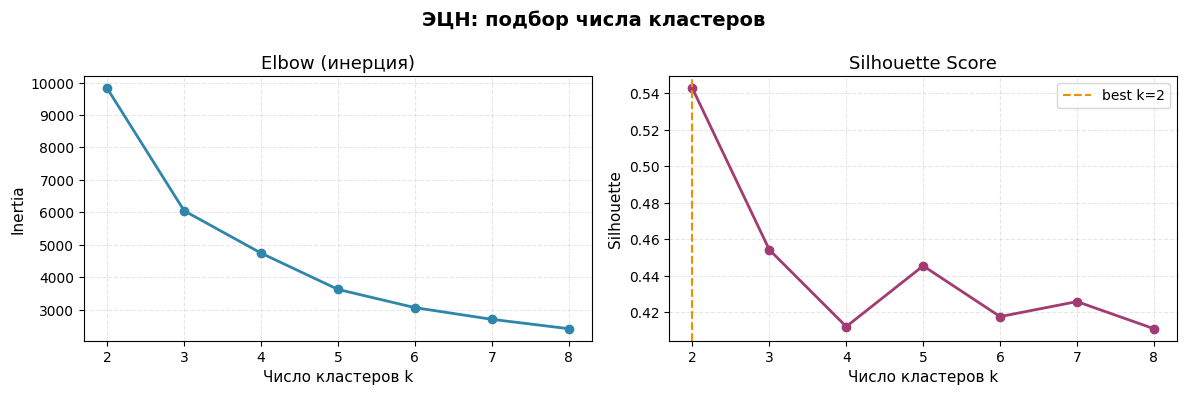

2026-02-25 20:43:07,164 - INFO - ЭЦН: лучший k по Silhouette = 2 (0.5426)


In [31]:
CLUSTERING_CONFIG.default_k["ecn"] = plot_elbow_silhouette(Z_ecn, "ЭЦН")

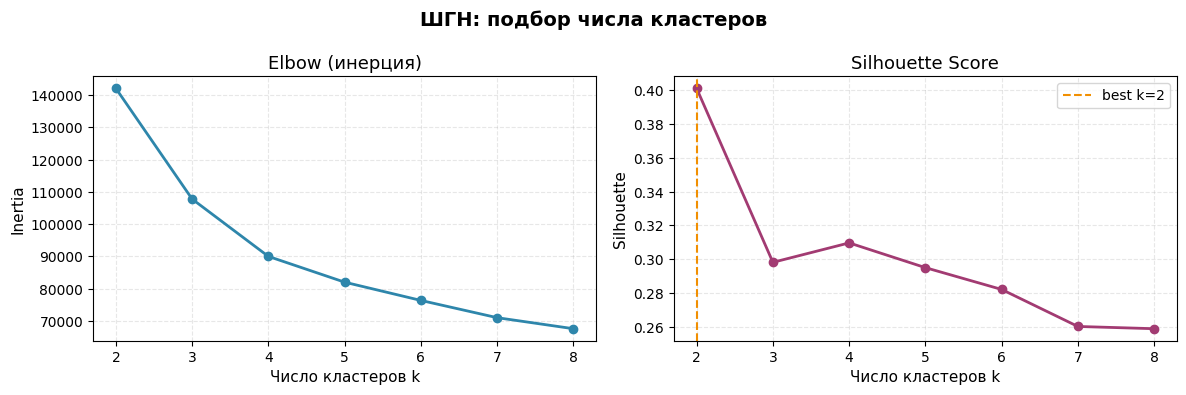

2026-02-25 20:53:52,069 - INFO - ШГН: лучший k по Silhouette = 2 (0.4010)


In [32]:
CLUSTERING_CONFIG.default_k["shgn"] = plot_elbow_silhouette(Z_shgn, "ШГН")

# ==== 4. K-MEANS КЛАСТЕРИЗАЦИЯ ====

In [33]:
def fit_kmeans(
    Z: np.ndarray,
    n_clusters: int,
    pump_type: str,
) -> tuple[KMeans, np.ndarray]:
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=CLUSTERING_CONFIG.seed,
        n_init=20,
    )
    labels = kmeans.fit_predict(Z)

    silhouette = silhouette_score(
        Z,
        labels,
        sample_size=min(5000, Z.shape[0]),
        random_state=CLUSTERING_CONFIG.seed,
    )
    davies_bouldin = davies_bouldin_score(Z, labels)
    calinski_harabasz = calinski_harabasz_score(Z, labels)

    logger.info(
        "%s | k=%d | Silhouette=%.4f | Davies-Bouldin=%.4f | Calinski-Harabasz=%.1f",
        pump_type,
        n_clusters,
        silhouette,
        davies_bouldin,
        calinski_harabasz,
    )
    return kmeans, labels

In [35]:
km_ecn, labels_ecn = fit_kmeans(Z_ecn, CLUSTERING_CONFIG.default_k["ecn"], "ЭЦН")
km_shgn, labels_shgn = fit_kmeans(Z_shgn, CLUSTERING_CONFIG.default_k["shgn"], "ШГН")

2026-02-25 20:55:13,792 - INFO - ЭЦН | k=2 | Silhouette=0.5426 | Davies-Bouldin=0.7015 | Calinski-Harabasz=1843.3
2026-02-25 20:55:14,163 - INFO - ШГН | k=2 | Silhouette=0.4010 | Davies-Bouldin=0.6350 | Calinski-Harabasz=3297.0


# ==== 4.5. ПОРОГИ ОТКЛОНЕНИЙ ПО КЛАСТЕРАМ ====

In [36]:
def compute_deviations(
    Z: np.ndarray,
    kmeans: KMeans,
    labels: np.ndarray,
) -> np.ndarray:
    deviations = np.zeros(Z.shape[0], dtype=np.float64)
    for cluster_index in range(kmeans.cluster_centers_.shape[0]):
        mask = labels == cluster_index
        center = kmeans.cluster_centers_[cluster_index]
        deviations[mask] = np.linalg.norm(Z[mask] - center, axis=1)
    return deviations

In [40]:
def compute_thresholds(
    deviations: np.ndarray,
    labels: np.ndarray,
    n_clusters: int,
    warn_percentile: float = 90.0,
    alert_percentile: float = 97.0,
) -> dict[int, dict[str, float]]:
    thresholds: dict[int, dict[str, float]] = {}
    for cluster_index in range(n_clusters):
        cluster_devs = deviations[labels == cluster_index]
        thresholds[cluster_index] = {
            "warn": float(np.percentile(cluster_devs, warn_percentile)),
            "alert": float(np.percentile(cluster_devs, alert_percentile)),
            "mean": float(cluster_devs.mean()),
            "std": float(cluster_devs.std()),
            "p50": float(np.percentile(cluster_devs, 50.0)),
        }
    return thresholds

In [41]:
def plot_deviation_histograms(
    deviations: np.ndarray,
    labels: np.ndarray,
    thresholds: dict[int, dict[str, float]],
    pump_type: str,
    n_clusters: int,
) -> None:
    fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 4), sharey=False)
    axes_list: list[plt.Axes] = axes.tolist() if n_clusters > 1 else [axes]

    for cluster_index, ax in enumerate(axes_list):
        cluster_devs = deviations[labels == cluster_index]
        color = CLUSTER_PALETTE[cluster_index % len(CLUSTER_PALETTE)]

        ax.hist(cluster_devs, bins=60, color=color, alpha=0.7, edgecolor="none")
        ax.axvline(
            thresholds[cluster_index]["warn"],
            color="#f39c12",
            linewidth=2,
            linestyle="--",
            label=f"Warn p90={thresholds[cluster_index]['warn']:.3f}",
        )
        ax.axvline(
            thresholds[cluster_index]["alert"],
            color="#e74c3c",
            linewidth=2,
            linestyle="--",
            label=f"Alert p97={thresholds[cluster_index]['alert']:.3f}",
        )
        ax.set_title(f"Кластер {cluster_index} (n={int((labels == cluster_index).sum())})")
        ax.set_xlabel("Deviation (L2 до центроида)")
        ax.set_ylabel("Число окон")
        ax.legend(fontsize=9)

    fig.suptitle(f"{pump_type}: распределение отклонений по кластерам", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

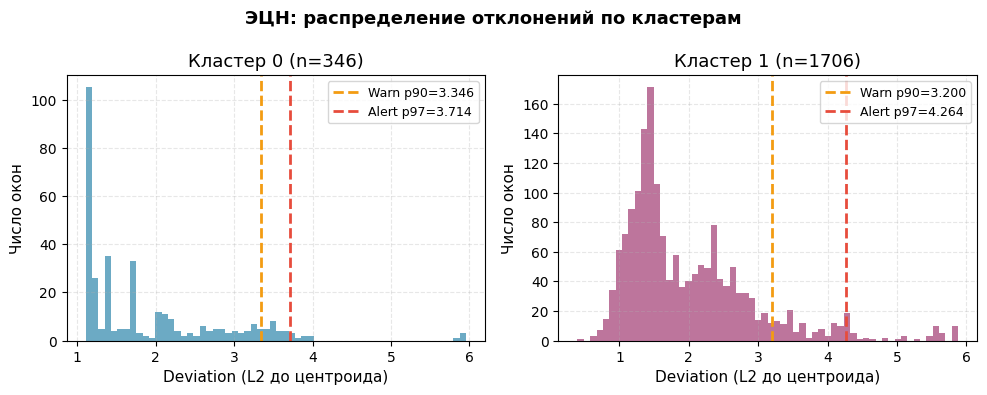

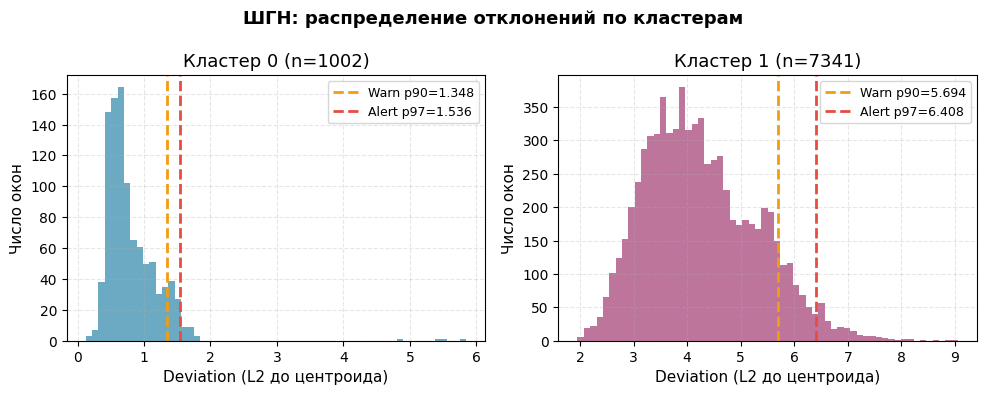

2026-02-25 21:00:28,013 - INFO - ЭЦН пороги:
2026-02-25 21:00:28,013 - INFO -   Кластер 0 | warn=3.3464 | alert=3.7135 | mean=1.8983 | std=0.9165
2026-02-25 21:00:28,014 - INFO -   Кластер 1 | warn=3.1997 | alert=4.2643 | mean=1.9885 | std=0.9491
2026-02-25 21:00:28,014 - INFO - ШГН пороги:
2026-02-25 21:00:28,015 - INFO -   Кластер 0 | warn=1.3479 | alert=1.5365 | mean=0.8067 | std=0.4418
2026-02-25 21:00:28,015 - INFO -   Кластер 1 | warn=5.6944 | alert=6.4084 | mean=4.2615 | std=1.0392


In [42]:
devs_ecn = compute_deviations(Z_ecn, km_ecn, labels_ecn)
devs_shgn = compute_deviations(Z_shgn, km_shgn, labels_shgn)

thresholds_ecn = compute_thresholds(devs_ecn, labels_ecn, CLUSTERING_CONFIG.default_k["ecn"])
thresholds_shgn = compute_thresholds(devs_shgn, labels_shgn, CLUSTERING_CONFIG.default_k["shgn"])

plot_deviation_histograms(devs_ecn, labels_ecn, thresholds_ecn, "ЭЦН", CLUSTERING_CONFIG.default_k["ecn"])
plot_deviation_histograms(devs_shgn, labels_shgn, thresholds_shgn, "ШГН", CLUSTERING_CONFIG.default_k["shgn"])

for pump_type, thr in (("ЭЦН", thresholds_ecn), ("ШГН", thresholds_shgn)):
    logger.info("%s пороги:", pump_type)
    for cluster_index, vals in thr.items():
        logger.info(
            "  Кластер %d | warn=%.4f | alert=%.4f | mean=%.4f | std=%.4f",
            cluster_index,
            vals["warn"],
            vals["alert"],
            vals["mean"],
            vals["std"],
        )

# ==== 5. ВИЗУАЛИЗАЦИЯ ЛАТЕНТНОГО ПРОСТРАНСТВА ====

In [43]:
def _reduce_to_2d(Z: np.ndarray, method: str) -> tuple[np.ndarray, str]:
    if method == "PCA":
        reducer_pca = PCA(n_components=2, random_state=CLUSTERING_CONFIG.seed)
        Z_2d = np.asarray(reducer_pca.fit_transform(Z))
        explained = float(reducer_pca.explained_variance_ratio_.sum())
        return Z_2d, f"PCA (объяснённая дисперсия: {explained:.1%})"

    reducer_umap = UMAP(
        n_components=2,
        random_state=CLUSTERING_CONFIG.seed,
        n_neighbors=30,
        min_dist=0.1,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        Z_2d = np.asarray(reducer_umap.fit_transform(Z))
    return Z_2d, "UMAP"


def plot_latent_space(
    Z: np.ndarray,
    labels: np.ndarray,
    pump_type: str,
    method: str = "PCA",
) -> None:
    Z_2d, subtitle = _reduce_to_2d(Z, method)
    unique_labels = np.unique(labels)

    fig, ax = plt.subplots(figsize=(10, 7))
    for cluster_index in unique_labels:
        mask = labels == cluster_index
        ax.scatter(
            Z_2d[mask, 0],
            Z_2d[mask, 1],
            c=CLUSTER_PALETTE[int(cluster_index) % len(CLUSTER_PALETTE)],
            label=f"Кластер {int(cluster_index)} (n={int(mask.sum())})",
            alpha=0.5,
            s=8,
            rasterized=True,
        )

    ax.set_title(f"{pump_type}: латентное пространство — {subtitle}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Компонента 1")
    ax.set_ylabel("Компонента 2")
    ax.legend(markerscale=3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

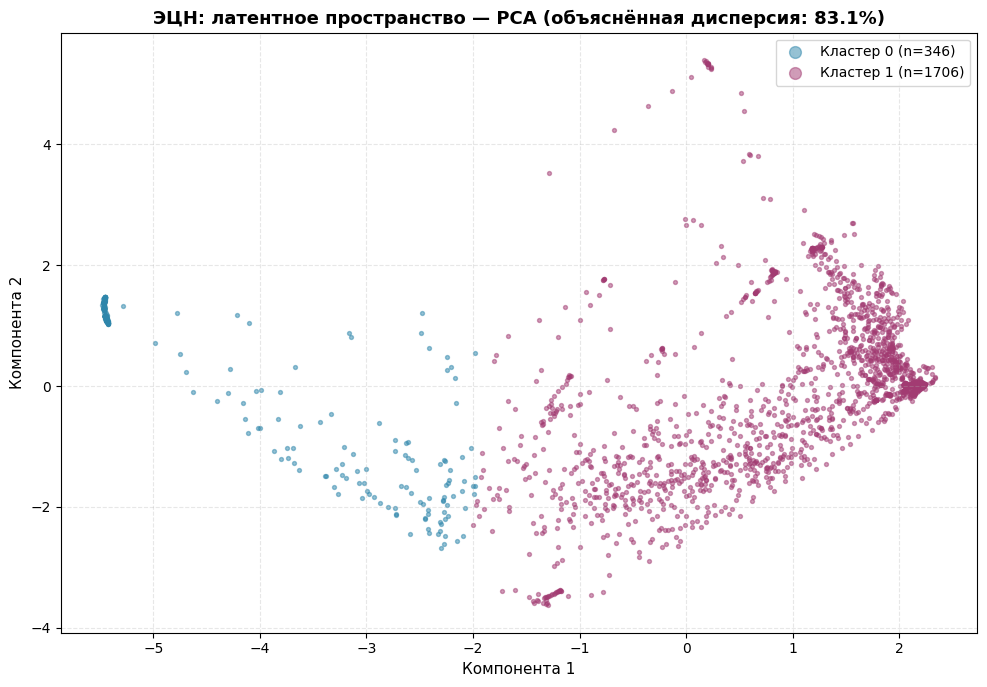

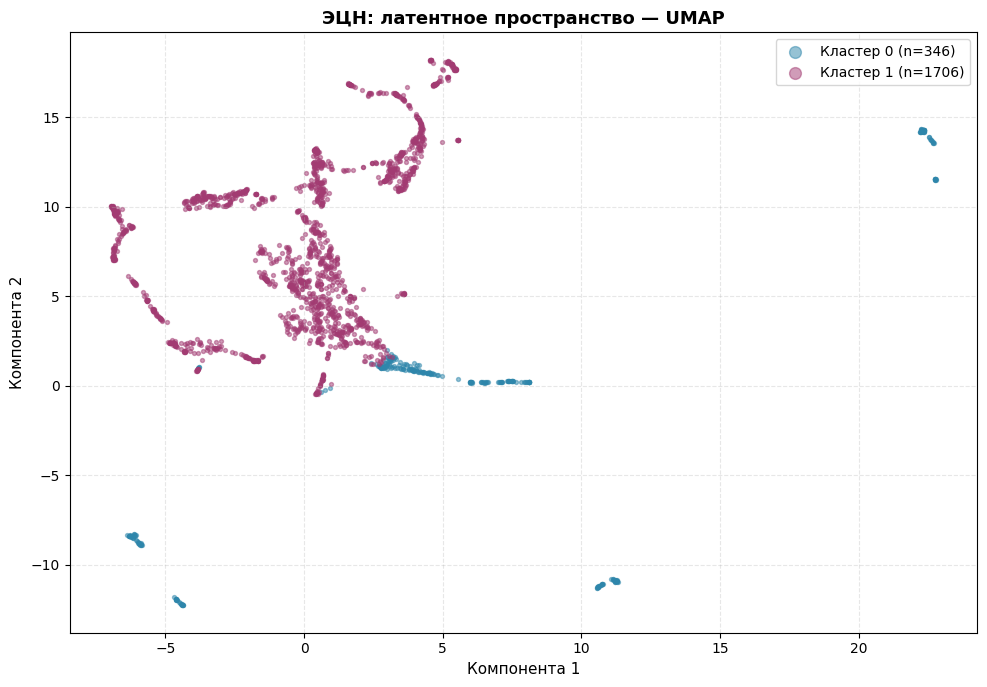

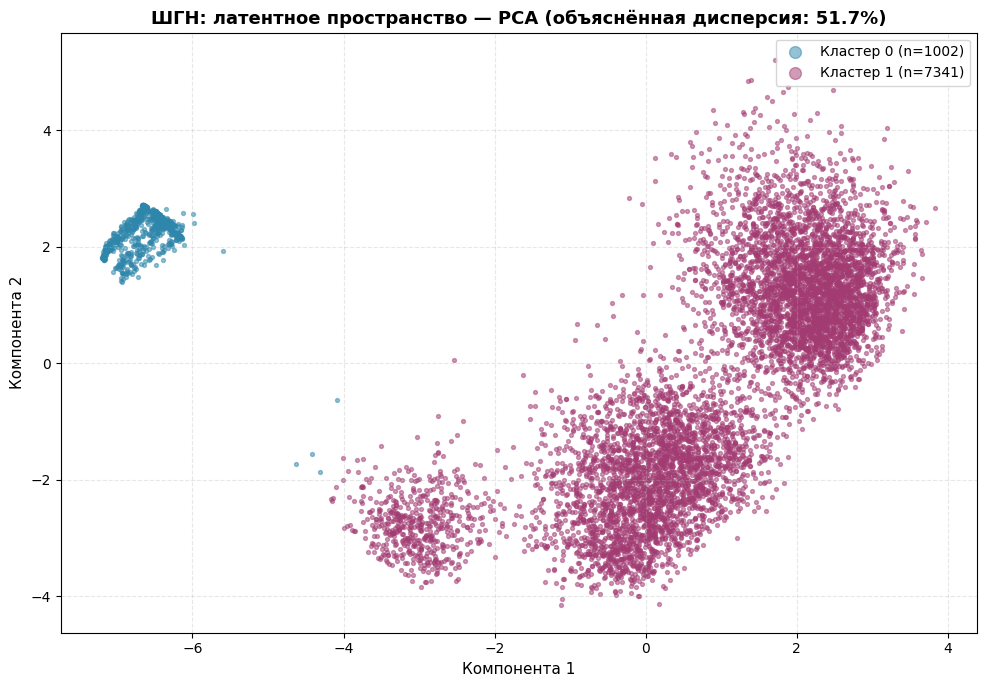

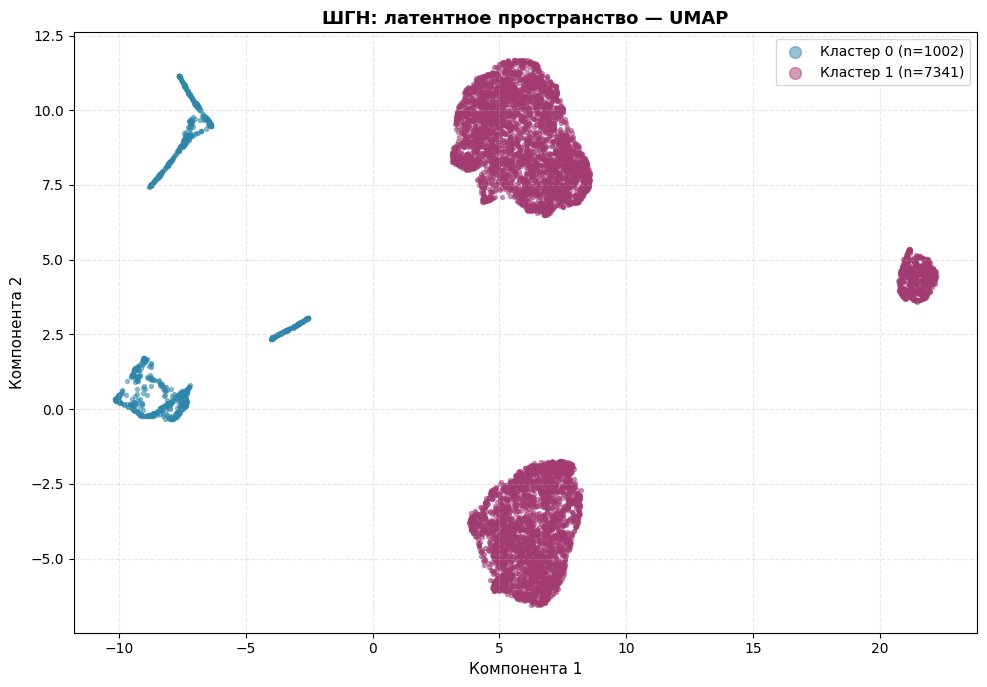

In [44]:
for pump_type, Z_latent, labels_latent in (("ЭЦН", Z_ecn, labels_ecn), ("ШГН", Z_shgn, labels_shgn)):
    for method in ("PCA", "UMAP"):
        plot_latent_space(Z_latent, labels_latent, pump_type, method)

# ==== 6. ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ ====

In [45]:
def decode_centroid_by_nearest(
    Z: np.ndarray,
    X: np.ndarray,
    centroid: np.ndarray,
    n_neighbors: int = 50,
) -> np.ndarray:
    distances = np.linalg.norm(Z - centroid, axis=1)
    nearest_indices = np.argsort(distances)[:n_neighbors]
    return X[nearest_indices].mean(axis=0)

In [46]:
def plot_cluster_profiles(
    Z: np.ndarray,
    X: np.ndarray,
    kmeans: KMeans,
    pump_type: str,
    n_clusters: int,
    n_neighbors: int = 50,
) -> None:
    steps = np.arange(X.shape[1])
    fig, axes = plt.subplots(n_clusters, len(DATA_CONFIG.feature_columns), figsize=(22, 3 * n_clusters))

    for cluster_index in range(n_clusters):
        profile = decode_centroid_by_nearest(
            Z,
            X,
            kmeans.cluster_centers_[cluster_index],
            n_neighbors,
        )
        row_axes: list[plt.Axes] = axes[cluster_index].tolist() if n_clusters > 1 else [axes]  # type: ignore[index]

        for feature_index, feature in enumerate(DATA_CONFIG.feature_columns):
            ax = row_axes[feature_index]
            ax.plot(
                steps,
                profile[:, feature_index],
                color=CLUSTER_PALETTE[cluster_index % len(CLUSTER_PALETTE)],
                linewidth=1.5,
            )
            if cluster_index == 0:
                ax.set_title(feature, fontsize=9, fontweight="bold")
            if feature_index == 0:
                ax.set_ylabel(f"Кластер {cluster_index}", fontsize=9)

    fig.suptitle(f"{pump_type}: типовые профили кластеров", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

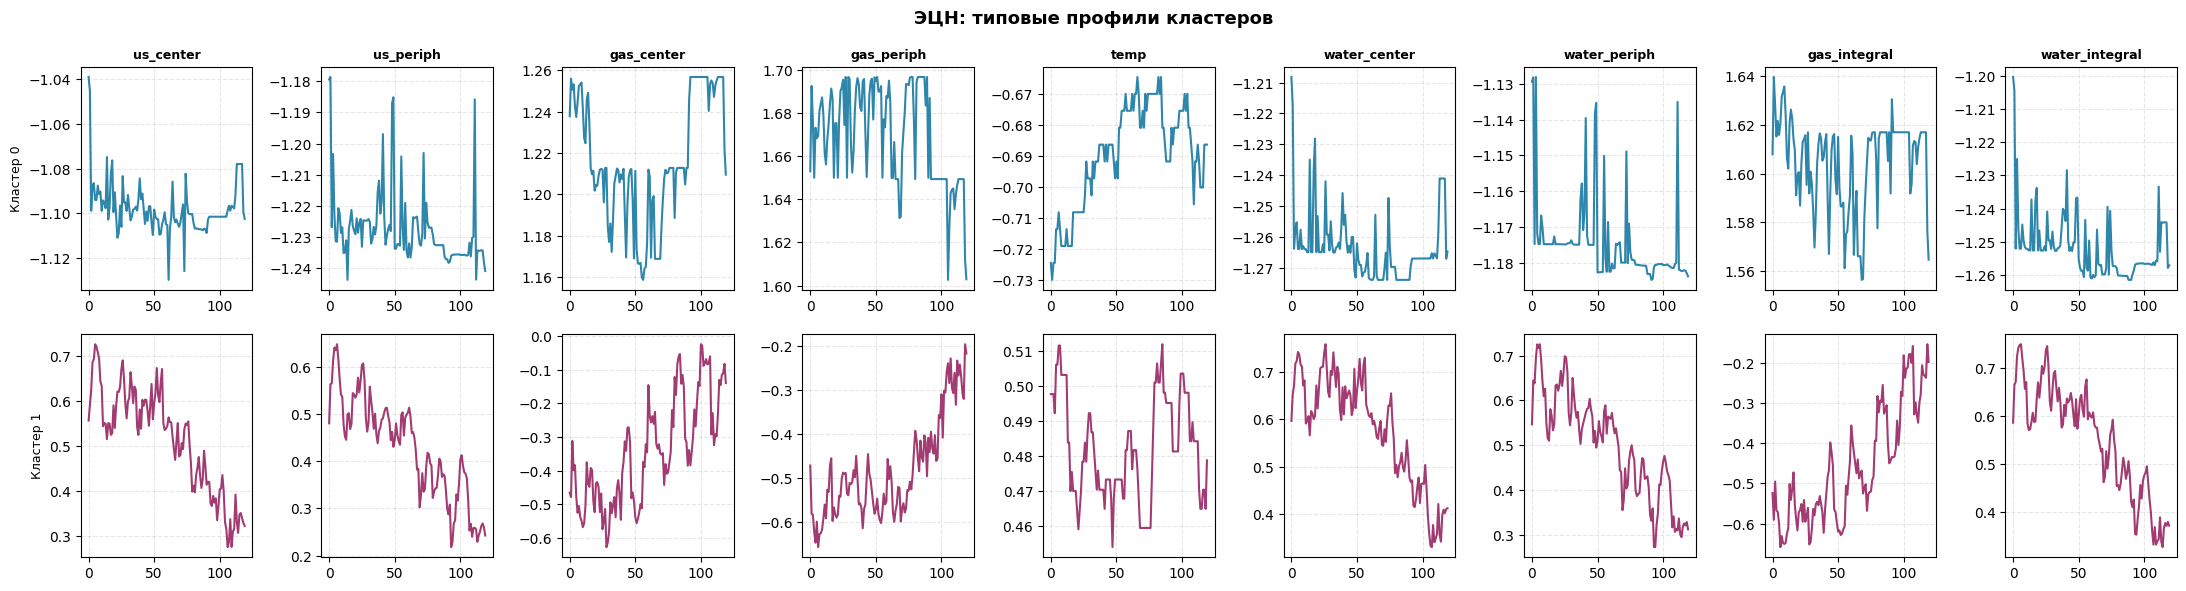

In [47]:
plot_cluster_profiles(
    Z_ecn,
    X_ecn,
    km_ecn,
    "ЭЦН",
    CLUSTERING_CONFIG.default_k["ecn"],
)

| Кластер | Состояние              | Обоснование                                                                                                                                                     |
| ------- | ---------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 0       | Выключена / простои | Все параметры около постоянных отрицательных значений без тренда по времени; профиль по каждому признаку почти плоский, что соответствует неработающему насосу. |
| 1       | Стабильная работа ЭЦН  | Давления и интегралы жидкости положительные и медленно убывают/растут по времени, без резких скачков; формы кривых гладкие, с умеренной вариативностью.         |

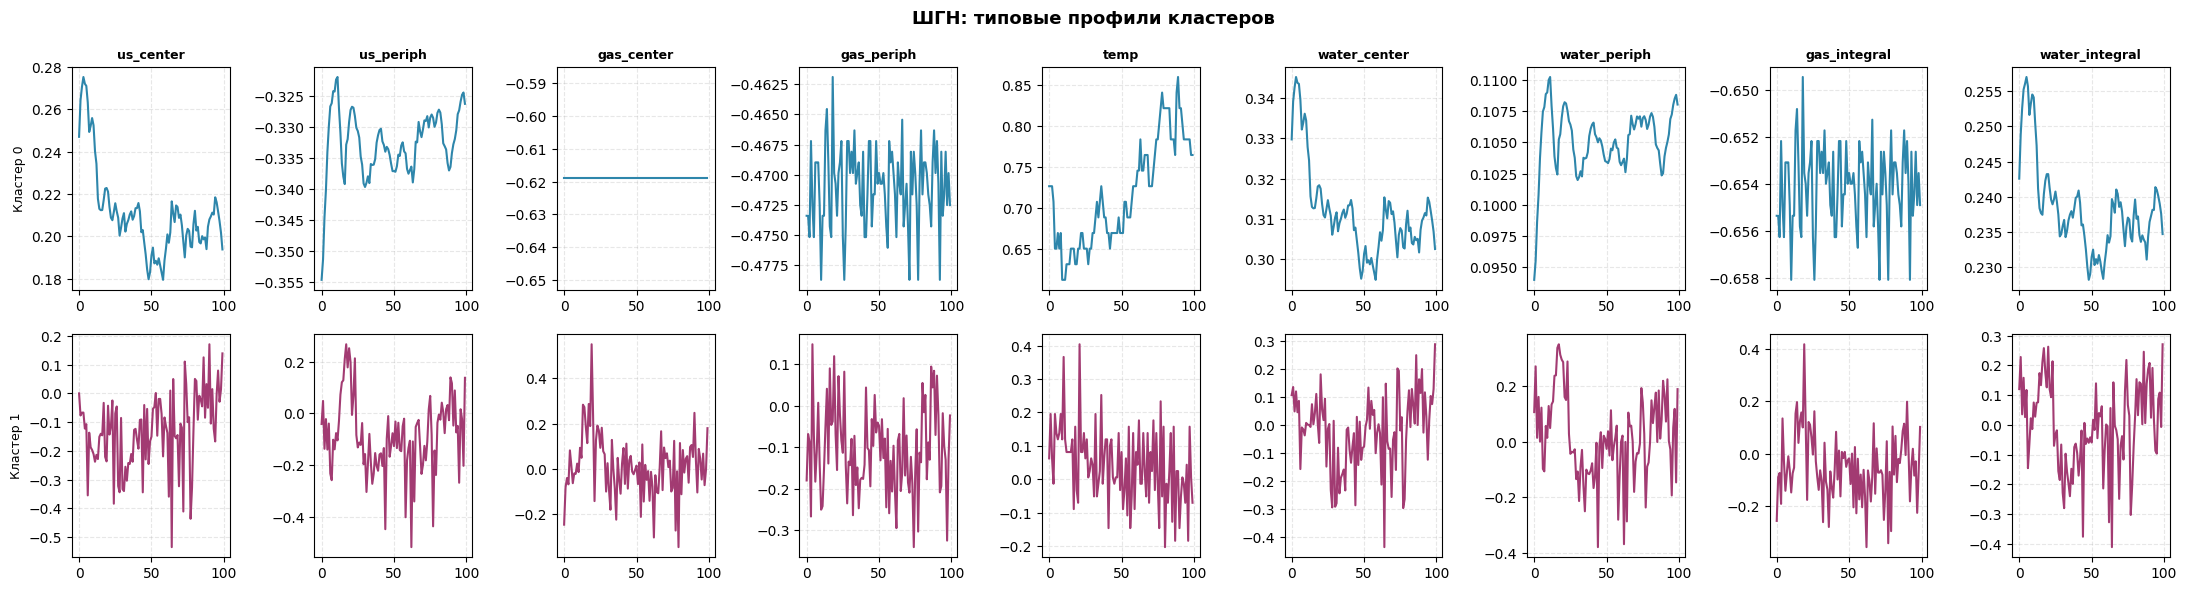

In [50]:
plot_cluster_profiles(
    Z_shgn,
    X_shgn,
    km_shgn,
    "ШГН",
    CLUSTERING_CONFIG.default_k["shgn"],
)

| Кластер | Состояние                                    | Обоснование                                                                                                                                                                         |
| ------- | -------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 0       | Стабильная жидкостная фаза (нефть/вода)      | УЗ и вода устойчиво смещены от нуля при очень малом Std, газ и его интеграл стабильно отрицательны, температура повышена — ровный рабочий режим с доминированием жидкости.          |
| 1       | Нестабильный переходный газожидкостный режим | Все параметры колеблются вокруг нуля с заметной дисперсией, газ и вода «шумят» без чёткого тренда, температура тоже плавает — типичная картина переходных газожидкостных состояний. |

# ==== 7. СТАТИСТИКА КЛАСТЕРОВ ====

In [53]:
def print_cluster_profiles_stats(
    Z: np.ndarray,
    X: np.ndarray,
    kmeans: KMeans,
    pump_type: str,
    n_neighbors: int = 120,
) -> None:
    rows: list[dict[str, object]] = []
    for cluster_index in range(kmeans.cluster_centers_.shape[0]):
        profile = decode_centroid_by_nearest(Z, X, kmeans.cluster_centers_[cluster_index], n_neighbors)
        for feature_index, feature in enumerate(DATA_CONFIG.feature_columns):
            column_values = profile[:, feature_index]
            rows.append(
                {
                    "Кластер": cluster_index,
                    "Параметр": feature,
                    "Среднее": round(float(column_values.mean()), 4),
                    "Std": round(float(column_values.std()), 4),
                    "Min": round(float(column_values.min()), 4),
                    "Max": round(float(column_values.max()), 4),
                }
            )

    df = pd.DataFrame(rows)
    for cluster_index in range(kmeans.cluster_centers_.shape[0]):
        subset = df[df["Кластер"] == cluster_index][["Параметр", "Среднее", "Std", "Min", "Max"]]
        logger.info("\n%s | Кластер %d:\n%s", pump_type, cluster_index, subset.to_string(index=False))

In [54]:
print_cluster_profiles_stats(Z_ecn, X_ecn, km_ecn, "ЭЦН")

2026-02-25 21:09:00,378 - INFO - 
ЭЦН | Кластер 0:
      Параметр  Среднее    Std     Min     Max
     us_center  -1.0926 0.0122 -1.1160 -1.0554
     us_periph  -1.2268 0.0109 -1.2438 -1.1980
    gas_center   1.2191 0.0136  1.1976  1.2385
    gas_periph   1.6751 0.0155  1.6378  1.6967
          temp  -0.6869 0.0112 -0.7129 -0.6628
  water_center  -1.2611 0.0106 -1.2739 -1.2271
  water_periph  -1.1717 0.0100 -1.1828 -1.1418
  gas_integral   1.6091 0.0082  1.5888  1.6291
water_integral  -1.2491 0.0102 -1.2613 -1.2166
2026-02-25 21:09:00,380 - INFO - 
ЭЦН | Кластер 1:
      Параметр  Среднее    Std     Min     Max
     us_center   0.5119 0.1230  0.2628  0.7355
     us_periph   0.4594 0.1061  0.2147  0.6489
    gas_center  -0.3619 0.1147 -0.5762 -0.1150
    gas_periph  -0.5011 0.0753 -0.6232 -0.2866
          temp   0.5772 0.0074  0.5662  0.5951
  water_center   0.5820 0.1113  0.3308  0.7750
  water_periph   0.5250 0.1140  0.2579  0.7344
  gas_integral  -0.4798 0.0995 -0.6393 -0.2490
water

In [55]:
print_cluster_profiles_stats(Z_shgn, X_shgn, km_shgn, "ШГН")

2026-02-25 21:10:02,376 - INFO - 
ШГН | Кластер 0:
      Параметр  Среднее    Std     Min     Max
     us_center   0.2521 0.0114  0.2377  0.2866
     us_periph  -0.3740 0.0035 -0.3869 -0.3656
    gas_center  -0.6190 0.0000 -0.6190 -0.6190
    gas_periph  -0.4702 0.0021 -0.4754 -0.4647
          temp   0.6775 0.0465  0.6094  0.7675
  water_center   0.3364 0.0061  0.3287  0.3546
  water_periph   0.0882 0.0017  0.0816  0.0921
  gas_integral  -0.6537 0.0011 -0.6564 -0.6509
water_integral   0.2433 0.0037  0.2384  0.2536
2026-02-25 21:10:02,380 - INFO - 
ШГН | Кластер 1:
      Параметр  Среднее    Std     Min    Max
     us_center  -0.1015 0.0825 -0.3666 0.1028
     us_periph  -0.0593 0.0871 -0.2534 0.1466
    gas_center  -0.0401 0.1135 -0.2879 0.3012
    gas_periph  -0.1233 0.0725 -0.3391 0.0752
          temp   0.0042 0.0751 -0.1656 0.2140
  water_center   0.0028 0.0837 -0.2612 0.1574
  water_periph   0.0310 0.0972 -0.1872 0.2498
  gas_integral  -0.0938 0.1025 -0.3328 0.1916
water_integral

# ==== 8. СОХРАНЕНИЕ АРТЕФАКТОВ ====

In [56]:
def save_artifacts(
    prefix: str,
    kmeans: KMeans,
    labels: np.ndarray,
    Z: np.ndarray,
) -> None:
    artifact_dir = DATA_CONFIG.models_dir / prefix
    artifact_dir.mkdir(exist_ok=True, parents=True)

    with open(artifact_dir / "kmeans.pkl", "wb") as f:
        pickle.dump(kmeans, f)

    np.save(artifact_dir / "labels.npy", labels)
    np.save(artifact_dir / "latents.npy", Z)

    logger.info("%s артефакты сохранены → %s", prefix.upper(), artifact_dir.absolute())
    logger.info(
        "  kmeans: %d кластеров | labels: %s | latents: %s",
        kmeans.cluster_centers_.shape[0],
        labels.shape,
        Z.shape,
    )


def save_thresholds(prefix: str, thresholds: dict[int, dict[str, float]]) -> None:
    path = DATA_CONFIG.models_dir / prefix / "thresholds.pkl"
    with open(path, "wb") as f:
        pickle.dump(thresholds, f)
    logger.info("%s пороги сохранены → %s", prefix.upper(), path)

In [57]:
save_artifacts("ecn", km_ecn, labels_ecn, Z_ecn)
save_artifacts("shgn", km_shgn, labels_shgn, Z_shgn)

2026-02-25 21:11:08,560 - INFO - ECN артефакты сохранены → c:\Users\aslan\Рабочий стол\Диплом\code\training\..\models\ecn
2026-02-25 21:11:08,561 - INFO -   kmeans: 2 кластеров | labels: (2052,) | latents: (2052, 32)
2026-02-25 21:11:08,565 - INFO - SHGN артефакты сохранены → c:\Users\aslan\Рабочий стол\Диплом\code\training\..\models\shgn
2026-02-25 21:11:08,565 - INFO -   kmeans: 2 кластеров | labels: (8343,) | latents: (8343, 32)


In [58]:
save_thresholds("ecn", thresholds_ecn)
save_thresholds("shgn", thresholds_shgn)

2026-02-25 21:11:09,445 - INFO - ECN пороги сохранены → ..\models\ecn\thresholds.pkl
2026-02-25 21:11:09,448 - INFO - SHGN пороги сохранены → ..\models\shgn\thresholds.pkl
